➡️ Phase 6 – Machine Learning (Scikit-Learn)

Scikit-Learn is not Machine Learning itself. It is the Python library we're using to learn and implement machine learning.
- ✅ Lesson 1 – What is Machine Learning?
- ✅ Lesson 2 – Features vs Target
- ✅ Lesson 3 – Train/Test Split
- ✅ Lesson 4 – Linear Regression
- ✅ Lesson 5 – Model Accuracy (R²)
- ✅ Lesson 6 – Classification
- ⬜ Lesson 7 – Decision Trees
- ⬜ Lesson 8 – Random Forests
- ⬜ Lesson 9 – Feature Engineering
- ⬜ Lesson 10 – End-to-End Project

➡️ Lesson 1 – What is Machine Learning?

**Traditional Programming**

Data
->
Rules
->
Answer

**Machine Learning**

Historical Data
      ->
Model Training
      ->
Model
      ->
Predictions

**Key Vocabulary**

Feature = Input variable.

Target = What we want to predict (Output).

Model = The learned relationship.

In [1]:
from sklearn.linear_model import LinearRegression
import pandas as pd

In [2]:
#Create data
df = pd.DataFrame({
    "Experience": [1,2,3,4,5],
    "Salary": [50000,60000,70000,80000,90000]
})

In [6]:
X = df[["Experience"]]    #Create Feature Matrix
type(X)     #X is stored as a Pandas DataFrame, but in machine learning we view that DataFrame as a matrix containing feature values.

pandas.core.frame.DataFrame

In [9]:
y = df["Salary"]      #Create Target Vector
y

,Salary
0,50000
1,60000
2,70000
3,80000
4,90000


In [10]:
X

,Experience
0,1
1,2
2,3
3,4
4,5


Pandas Name ****ML Name

- Series      -> Vector
- DataFrame   -> Matrix
- Column      -> Feature
- Row         -> Observation (Sample)

In [11]:
model = LinearRegression()

model.fit(X, y)     #Train Model

LinearRegression()

In [15]:
new_data = pd.DataFrame({
    "Experience": [6]
})

model.predict(new_data)


array([100000.])

Pandas DataFrame
      ->
Feature (X)

Pandas Series
      ->
Target (y)

model.fit(X,y)
      ->
Training

model.predict()
      ->
Prediction

⬜ Lesson 2 – Features vs Target

In [16]:
#Multiple Features Example
df = pd.DataFrame({
    "Experience": [1,2,3,4,5],
    "Age": [25,28,30,35,40],
    "Education": [12,14,16,16,18],
    "Salary": [50000,60000,70000,80000,90000]
})


In [17]:
#Features, Double Brackets = DataFrame
X = df[["Experience",
        "Age",
        "Education"]]

In [19]:
#Target, Single brackets = Series
y = df["Salary"]

➡️ Next: Lesson 3 – Train/Test Split

Split data into two groups:
- All Data

- 80% → Training Data
- 20% → Testing Data

In [20]:
import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6,7,8,9,10],
    "Salary": [50000,60000,70000,80000,90000,
               100000,110000,120000,130000,140000]
})

In [21]:
X = df[["Experience"]]    #Create Features and Target
y = df["Salary"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      #20% Test Data, 80% Training Data
    random_state=42     # seed, Use same random split every run, This makes results reproducible.
)

In [24]:
X_train

,Experience
5,6
0,1
7,8
2,3
9,10
4,5
3,4
6,7


In [25]:
X_test

,Experience
8,9
1,2


In [28]:
y_train

,Salary
5,100000
0,50000
7,120000
2,70000
9,140000
4,90000
3,80000
6,110000


In [29]:
y_test

,Salary
8,130000
1,60000


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)     #Train the Model

LinearRegression()

In [30]:
predictions = model.predict(X_test)     #Make Predictions

predictions

array([130000.,  60000.])

In [32]:
import pandas as pd
#Compare Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results

,Actual,Predicted
8,130000,130000.0
1,60000,60000.0


➡️ Next: Lesson 4 – Linear Regression Details

In [35]:
#View the Slope
model.coef_     #coef_= slope. For each additional year of experience, salary increases by $10,000

array([10000.])

In [36]:
model.intercept_    #View the Intercept, Starting salary = $40,000


np.float64(40000.00000000001)

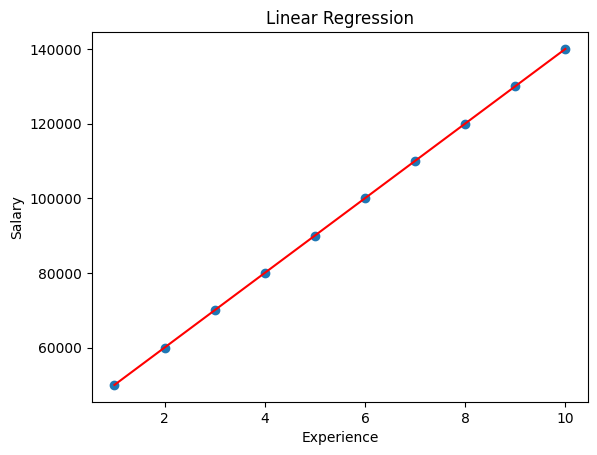

In [43]:
import matplotlib.pyplot as plt

plt.scatter(df["Experience"], df["Salary"])
#Dots = actual data
#Red line = model
plt.plot(
    df["Experience"],
    model.predict(X),
    color="red"
)

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")

plt.show()

➡️ Next: Lesson 5 – Model Accuracy (R² Score)

Now we answer the question every Machine Learning project eventually asks:

"How good is my model?"

R² (R-Squared) measures how well a model explains the data.

1.0  = Perfect

0.9  = Very Good

0.5  = Okay

0.0  = No Better Than Guessing

How much of the variation in y
can be explained by X?

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6,7,8,9,10],
    "Salary": [50000,60000,70000,80000,90000,
               100000,112000,120000,130000,148000]
})

X = df[["Experience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

score = r2_score(y_test, predictions)

print(score)

0.9942030867043606


➡️ Next: Lesson 6 – Classification

Regression vs Classification

Regression - Predicts a number:

Classification - Predicts a category:

In [52]:
import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6],
    "Approved": [0,0,0,1,1,1]
})

df


,Experience,Approved
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
5,6,1


In [53]:
X = df[["Experience"]]      #Create X and y

y = df["Approved"]

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X, y)

LogisticRegression(max_iter=1000)

In [57]:
new_data = pd.DataFrame({
"Experience": [6]
})
model.predict(new_data)

array([1])

In [58]:
new_data = pd.DataFrame({
"Experience": [0]
})
model.predict(new_data)

array([0])

⬜ Lesson 7 – Decision Trees

What is a Decision Tree?

A Decision Tree is basically a series of IF statements.

In [59]:
import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6],
    "Approved": [0,0,0,1,1,1]
})


In [60]:
X = df[["Experience"]]    #Features and Target

y = df["Approved"]

In [62]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X, y)     #Train Decision Tree

DecisionTreeClassifier()

In [66]:
new_data = pd.DataFrame({
"Experience": [-9]
})
model.predict(new_data)     #Make Predictions

array([0])

In [65]:
new_data = pd.DataFrame({
"Experience": [8]
})
model.predict(new_data)  #Make Predictions

array([1])

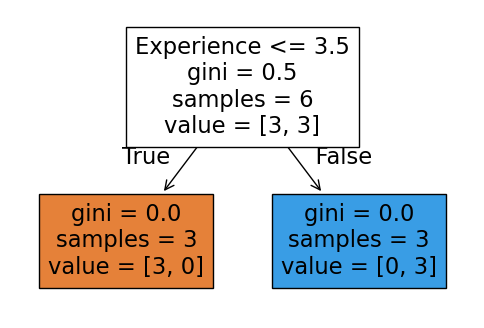

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plot_tree(
    model,
    feature_names=["Experience"],
    filled=True
)

plt.show()

##Decision Tree vs Logistic Regression##
**Logistic Regression**

Uses math equations

Input -> Probability -> Prediction

**Decision Tree**

Uses rules

IF, THEN, ELSE

➡️ Next: Lesson 8 – Random Forests

**Decision Tree** -> One person's opinion

**Random Forest** -> 100 people's opinions -> Vote
- Many Decision Trees
- Combined Predictions
- Final Answer

In [69]:
import pandas as pd
#Create Data
df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6],
    "Approved": [0,0,0,1,1,1]
})

X = df[["Experience"]]
y = df["Approved"]

In [70]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,   #Build 100 decision trees
    random_state=42     #Use the same randomness every run
)
#Train Random Forest
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [73]:
new_data = pd.DataFrame({
"Experience": [-9]
})
model.predict(new_data)     #Make Predictions

array([0])

In [74]:
new_data = pd.DataFrame({
"Experience": [7]
})
model.predict(new_data)     #Make Predictions

array([1])

In [77]:
new_data = pd.DataFrame({
"Experience": [7]
})
model.predict_proba(new_data)     #Probability  2% No 98% Yes Very confident.

array([[0.02, 0.98]])

In [78]:
model.feature_importances_    #1. = 100%

array([1.])

In [79]:
import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6,7,8],
    "Age":        [22,24,26,28,30,32,34,36],
    "Approved":   [0,0,0,0,1,1,1,1]
})


In [80]:
X = df[["Experience", "Age"]]
y = df["Approved"]

In [81]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

RandomForestClassifier(random_state=42)

In [82]:
model.feature_importances_   #Experience = 49% Age = 51%

array([0.49, 0.51])

In [83]:
for feature, importance in zip(X.columns, model.feature_importances_):
    print(feature, importance)

Experience 0.49
Age 0.51


In [92]:
df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6,7,8],
    "Age":        [50,20,60,25,45,30,65,35],
    "Approved":   [0,0,0,0,1,1,1,1]
})
X = df[["Experience", "Age"]]
y = df["Approved"]

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

RandomForestClassifier(random_state=42)

In [88]:
for feature, importance in zip(X.columns, model.feature_importances_):
    print(feature, importance) #Experience is doing almost all the predictive work.

Experience 0.6659015873015872
Age 0.3340984126984128


⬜ Lesson 9 – Feature Engineering

Better Features    > Better Algorithms

improving the input data helps more than switching from
- Decision Tree -> Random Forest
- Random Forest -> Neural Network

##What is a Feature?##

A feature is simply an input column.

In [106]:
import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6],
    "Age": [22,24,26,28,30,32],
    "Salary": [50000,60000,70000,80000,90000,100000]
})
X = df[["Experience", "Age"]]
y = df["Salary"]
#See Correlation
df.corr(numeric_only=True)      #Closer to 1 -> Strong relationship; Closer to 0 -> Weak relationship

,Experience,Age,Salary
Experience,1.0,1.0,1.0
Age,1.0,1.0,1.0
Salary,1.0,1.0,1.0


In [107]:
df["Age"]

,Age
0,22
1,24
2,26
3,28
4,30
5,32


In [108]:
df["AgeSquared"] = df["Age"] ** 2  # add a feature

In [109]:
X = df[["Age", "AgeSquared"]]
df.corr(numeric_only=True)

,Experience,Age,Salary,AgeSquared
Experience,1.00000,1.00000,1.00000,0.99854
Age,1.00000,1.00000,1.00000,0.99854
Salary,1.00000,1.00000,1.00000,0.99854
AgeSquared,0.99854,0.99854,0.99854,1.00000


In [110]:
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [119]:
new_data = pd.DataFrame({
    "Age": [30],
    "AgeSquared": [3600]
})

model.predict(new_data)

array([90000])

⬜ Lesson 10 – End-to-End Project

Goal

Predict salary based on:

- Experience

- Age

using the complete ML workflow.

In [120]:
import pandas as pd

df = pd.DataFrame({
    "Experience": [1,2,3,4,5,6,7,8,9,10],
    "Age": [22,24,26,28,30,32,34,36,38,40],
    "Salary": [50000,60000,70000,80000,90000,
               100000,110000,120000,130000,140000]
})

df

,Experience,Age,Salary
0,1,22,50000
1,2,24,60000
2,3,26,70000
3,4,28,80000
4,5,30,90000
5,6,32,100000
6,7,34,110000
7,8,36,120000
8,9,38,130000
9,10,40,140000


In [121]:
#Create Features and Target
X = df[["Experience", "Age"]]
y = df["Salary"]

In [123]:
from sklearn.model_selection import train_test_split
#Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [126]:
from sklearn.linear_model import LinearRegression
#Train Model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [125]:
#Make Predictions
predictions = model.predict(X_test)

predictions

array([130000.,  60000.])

In [127]:
#Compare Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results

,Actual,Predicted
8,130000,130000.0
1,60000,60000.0


In [128]:
from sklearn.metrics import r2_score
#Measure Accuracy
score = r2_score(y_test, predictions)

print(score)

1.0


In [129]:
#Predict New Data

#Suppose a new employee has
#Experience = 12
#Age = 44

new_employee = pd.DataFrame({
    "Experience": [12],
    "Age": [44]
})

model.predict(new_employee)

array([160000.])

In [130]:
#See Feature Importance
model.coef_


array([2000., 4000.])

In [131]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [2000. 4000.]
Intercept: -39999.99999999994


In [132]:
equation = "Salary = "

terms = [
    f"{coef:.0f} × {feature}"
    for coef, feature in zip(model.coef_, X.columns)
]

equation += " + ".join(terms)
equation += f" + {model.intercept_:.0f}"

print(equation)

Salary = 2000 × Experience + 4000 × Age + -40000


In [133]:
for coef, feature in zip(model.coef_, X.columns):
    print(f"{feature}: {coef:.2f}")


Experience: 2000.00
Age: 4000.00
